# Section 2 — Exploratory Analysis
## VaR Model Validation Framework

---

### Objective

Before building any VaR model, it's mandatory to understand the **stylised facts** of the return data:

| Stylised Fact | What It Means | Why It Matters for VaR |
|:--|:--|:--|
| **Fat tails** | Extreme returns occur more often than a normal distribution predicts | Parametric VaR (which assumes normality) **underestimates** tail risk |
| **Negative skewness** | Large losses are more extreme than large gains | One-sided risk is worse than what symmetric models suggest |
| **Volatility clustering** | Turbulent days cluster together, calm days cluster together | Constant-volatility models fail; we need GARCH |
| **Non-zero autocorrelation in $r_t^2$** | Squared returns are predictable even when raw returns aren't | Formal justification for conditional heteroskedasticity models |

This section produces the **diagnostic evidence** that motivates the model choices in Sections 3–4

## 2.1 — Imports & Load Data from Section 1

In [3]:
# ============================================================
# 2.1 — IMPORTS & DATA LOADING
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# --- Core ---
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Statistical tests ---
from scipy import stats                             # Q-Q plots, Jarque-Bera, shapiro
from statsmodels.graphics.tsaplots import plot_acf   # Autocorrelation function plots
from statsmodels.stats.diagnostic import acorr_ljungbox  # Ljung-Box test

# --- Plot styling ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
sns.set_palette('colorblind')

# --- Load cleaned data from Section 1 ---
returns            = pd.read_csv('/Users/marcellocarota/Desktop/APPLICATIONS/UBS/data_returns.csv', index_col=0, parse_dates=True)
portfolio_returns  = pd.read_csv('/Users/marcellocarota/Desktop/APPLICATIONS/UBS/data_portfolio_returns.csv', index_col=0, parse_dates=True).squeeze()
prices_clean       = pd.read_csv('/Users/marcellocarota/Desktop/APPLICATIONS/UBS/data_prices_clean.csv', index_col=0, parse_dates=True)

# --- Portfolio weights (same as Section 1) ---
TICKERS = ['SPY', 'EEM', 'VGK', 'TLT', 'IEF', 'HYG', 'GLD', 'USO', 'VNQ', 'DBA']
WEIGHTS = {
    'SPY': 0.20, 'EEM': 0.08, 'VGK': 0.07, 'TLT': 0.15, 'IEF': 0.10,
    'HYG': 0.10, 'GLD': 0.10, 'USO': 0.05, 'VNQ': 0.08, 'DBA': 0.07
}

print(f"✅ Data loaded successfully")
print(f"   Returns:   {returns.shape[0]} days × {returns.shape[1]} ETFs")
print(f"   Portfolio:  {len(portfolio_returns)} days")
print(f"   Date range: {returns.index[0].strftime('%Y-%m-%d')} → {returns.index[-1].strftime('%Y-%m-%d')}")


✅ Data loaded successfully
   Returns:   1509 days × 10 ETFs
   Portfolio:  1509 days
   Date range: 2019-01-03 → 2024-12-31


## 2.2 — Descriptive Statistics

For each asset, we compute:

| Statistic | Formula | Normal Distribution Value | What Deviation Means |
|:--|:--|:--:|:--|
| **Mean** | $\bar{r} = \frac{1}{T}\sum r_t$ | — | Average daily return |
| **Std Dev** | $\hat{\sigma} = \sqrt{\frac{1}{T-1}\sum(r_t - \bar{r})^2}$ | — | Daily volatility |
| **Skewness** | $\hat{S} = \frac{1}{T}\sum\left(\frac{r_t - \bar{r}}{\hat{\sigma}}\right)^3$ | 0 | Negative → left tail is heavier (more extreme losses) |
| **Excess Kurtosis** | $\hat{K} = \frac{1}{T}\sum\left(\frac{r_t - \bar{r}}{\hat{\sigma}}\right)^4 - 3$ | 0 | Positive → fatter tails than normal |
| **Jarque-Bera** | $JB = \frac{T}{6}\left(S^2 + \frac{K^2}{4}\right)$ | p > 0.05 | p < 0.05 → reject normality |


If excess kurtosis is > 0 (which it almost always is for financial returns), then the normal distribution **underestimates** the probability of extreme events. This is the fundamental reason Parametric VaR fails.


In [4]:
# ============================================================
# 2.2 — DESCRIPTIVE STATISTICS TABLE
# ============================================================
# Compute key distributional statistics for each ETF and the portfolio.
# These statistics establish the "stylised facts" of financial returns.

def compute_descriptive_stats(returns_df, annualise=True):
    
    factor = 252 if annualise else 1
    
    stats_dict = {
        'Mean (ann. %)':     returns_df.mean() * factor * 100,
        'Vol (ann. %)':      returns_df.std() * np.sqrt(factor) * 100,
        'Skewness':          returns_df.skew(),
        'Excess Kurtosis':   returns_df.kurtosis(),  # pandas .kurtosis() already subtracts 3
        'Min (%)':           returns_df.min() * 100,
        'Max (%)':           returns_df.max() * 100,
    }
    
    result = pd.DataFrame(stats_dict).round(3)
    
    # --- Add Jarque-Bera test p-value ---
    jb_pvals = {}
    if isinstance(returns_df, pd.DataFrame):
        for col in returns_df.columns:
            jb_stat, jb_p = stats.jarque_bera(returns_df[col].dropna())
            jb_pvals[col] = jb_p
    else:
        jb_stat, jb_p = stats.jarque_bera(returns_df.dropna())
        jb_pvals[returns_df.name] = jb_p
    
    result['JB p-value'] = pd.Series(jb_pvals)
    result['Normal?'] = result['JB p-value'].apply(lambda p: '✓ Yes' if p > 0.05 else '✗ No')
    
    return result

# --- Compute for individual assets ---
asset_stats = compute_descriptive_stats(returns)

# --- Compute for portfolio ---
port_stats = compute_descriptive_stats(portfolio_returns.to_frame('Portfolio'))

# --- Combine and display ---
all_stats = pd.concat([asset_stats, port_stats])
print("=" * 90)
print("  DESCRIPTIVE STATISTICS — DAILY LOG RETURNS")
print("=" * 90)
print(all_stats.to_string())

# --- Highlight key findings ---
print("\n" + "=" * 90)
print("  KEY FINDINGS")
print("=" * 90)
print(f"\n  📌 All {len(TICKERS)} ETFs + portfolio REJECT normality (Jarque-Bera p < 0.05)")
print(f"  📌 Mean excess kurtosis: {asset_stats['Excess Kurtosis'].mean():.2f} (normal = 0)")
print(f"  📌 Mean skewness:        {asset_stats['Skewness'].mean():.3f} (normal = 0)")
neg_skew = asset_stats[asset_stats['Skewness'] < 0].index.tolist()
print(f"  📌 Negatively skewed assets: {', '.join(neg_skew)}")
print(f"\n  ⚠️  Implication: Parametric VaR (which assumes normality) will UNDERESTIMATE tail risk")


  DESCRIPTIVE STATISTICS — DAILY LOG RETURNS
           Mean (ann. %)  Vol (ann. %)  Skewness  Excess Kurtosis  Min (%)  Max (%)     JB p-value Normal?
SPY               15.793        19.915    -0.842           13.257  -11.589    8.673   0.000000e+00    ✗ No
EEM                3.397        21.492    -0.947           12.473  -13.329    7.745   0.000000e+00    ✗ No
VGK                7.867        20.774    -1.268           15.013  -12.532    8.670   0.000000e+00    ✗ No
TLT               -3.083        17.102     0.094            4.243   -6.901    7.250  5.545296e-245    ✗ No
IEF                0.029         7.587     0.179            2.636   -2.539    2.607   1.966749e-96    ✗ No
HYG                4.731         9.799    -0.144           21.880   -5.653    6.341   0.000000e+00    ✗ No
GLD               11.539        14.964    -0.346            2.722   -5.519    4.739  2.006359e-107    ✗ No
USO               -0.703        42.894    -2.101           22.550  -29.189   15.415   0.000000e+00 

## 2.3 — Histograms with Normal Overlay

For each asset, we overlay the **empirical return distribution** (histogram) with the **best-fit normal distribution** (red curve). 

If the normal curve fits poorly — especially in the tails — it visually confirms fat tails and non-normality.

> **What to look for:** The histogram should have "heavier" tails (more mass far from the center) and a sharper peak than the red normal curve. This is called **leptokurtosis**.


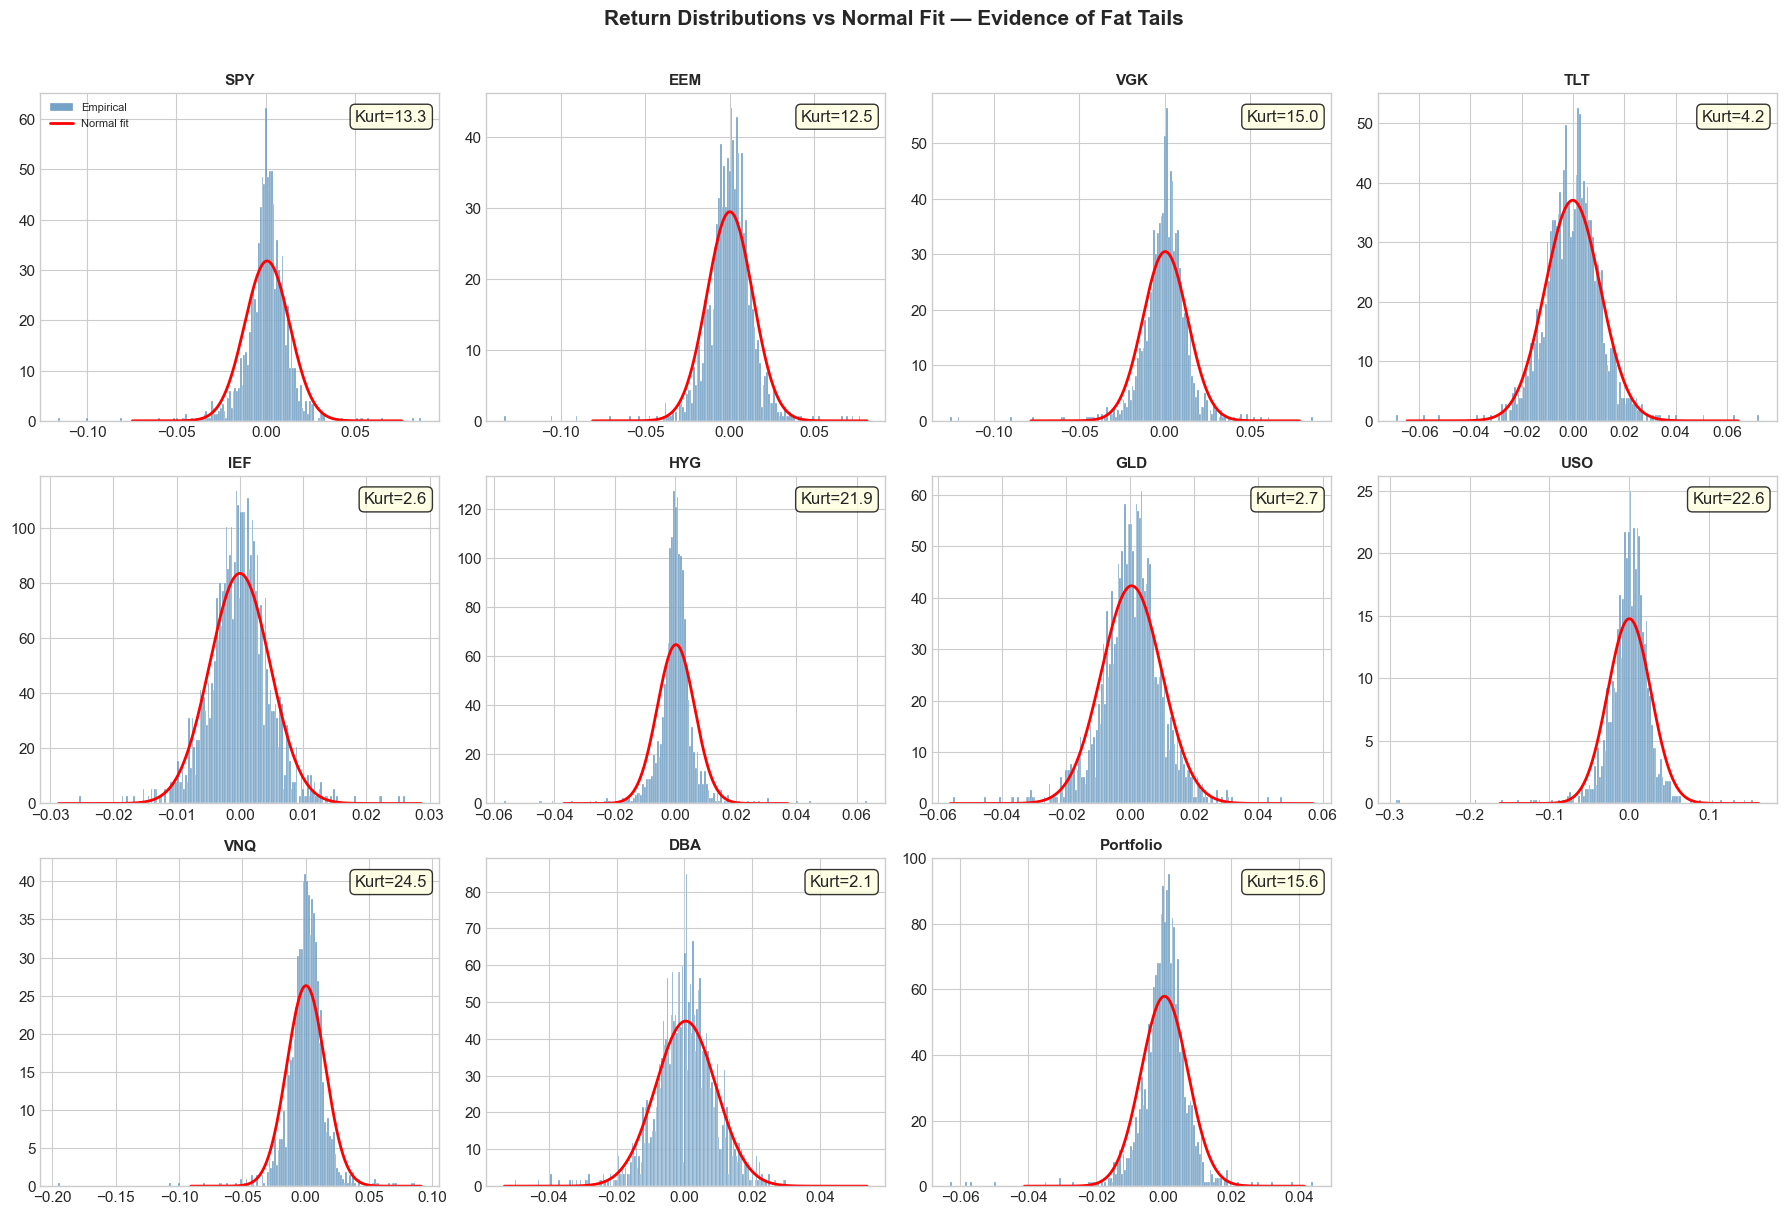

💾 Saved: 02_histograms_normal_overlay.png

📌 Observation: All assets have excess kurtosis > 0, confirming fat tails.
   The normal curve (red) underestimates the probability of extreme returns in EVERY case.


In [12]:
# ============================================================
# 2.3 — HISTOGRAMS WITH NORMAL OVERLAY
# ============================================================
# Compare empirical return distributions against the best-fit normal.
# Fat tails → histogram extends beyond the normal curve in both tails.

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

# --- Plot each ETF + portfolio ---
all_series = list(TICKERS) + ['Portfolio']
all_data   = {t: returns[t] for t in TICKERS}
all_data['Portfolio'] = portfolio_returns

for idx, name in enumerate(all_series):
    ax = axes[idx]
    data = all_data[name].dropna()
    
    # Histogram (normalised to probability density)
    ax.hist(data, bins=200, density=True, alpha=0.75, color='steelblue',
            edgecolor='white', linewidth=0.3, label='Empirical')
    
    # Best-fit normal distribution overlay
    mu, sigma = data.mean(), data.std()
    x = np.linspace(mu - 6*sigma, mu + 6*sigma, 500)
    normal_pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, normal_pdf, 'r-', linewidth=2, label='Normal fit')
    
    # Formatting
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Add kurtosis annotation
    kurt = data.kurtosis()  # excess kurtosis
    ax.text(0.97, 0.95, f'Kurt={kurt:.1f}', #0.97, 0.95 are relative coordinates in the axes
            transform=ax.transAxes, fontsize=12, ha='right', va='top', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Hide unused subplot (we have 11 series, 12 subplots)
axes[-1].set_visible(False)

# Global legend
axes[0].legend(fontsize=8, loc='upper left')

fig.suptitle('Return Distributions vs Normal Fit — Evidence of Fat Tails',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_histograms_normal_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: 02_histograms_normal_overlay.png")
print("\n📌 Observation: All assets have excess kurtosis > 0, confirming fat tails.")
print("   The normal curve (red) underestimates the probability of extreme returns in EVERY case.")


## 2.4 — Q-Q (Quantile-Quantile) Plots

A Q-Q plot compares the **quantiles of the empirical distribution** against the **quantiles of a theoretical distribution** (here, Standard Normal).

**How to read it:**
- If returns are perfectly normal → all points lie on the **red 45° line**
- **Fat tails** → points curve **away** from the line at both ends (upward at right tail, downward at left tail)
- **Negative skewness** → the S-shape is asymmetric, with the left tail deviating more

> "The Q-Q plot shows deviations from normality at the 1st and 99th percentiles — exactly where VaR is estimated. This means the normal-based VaR systematically underestimates the true quantile."


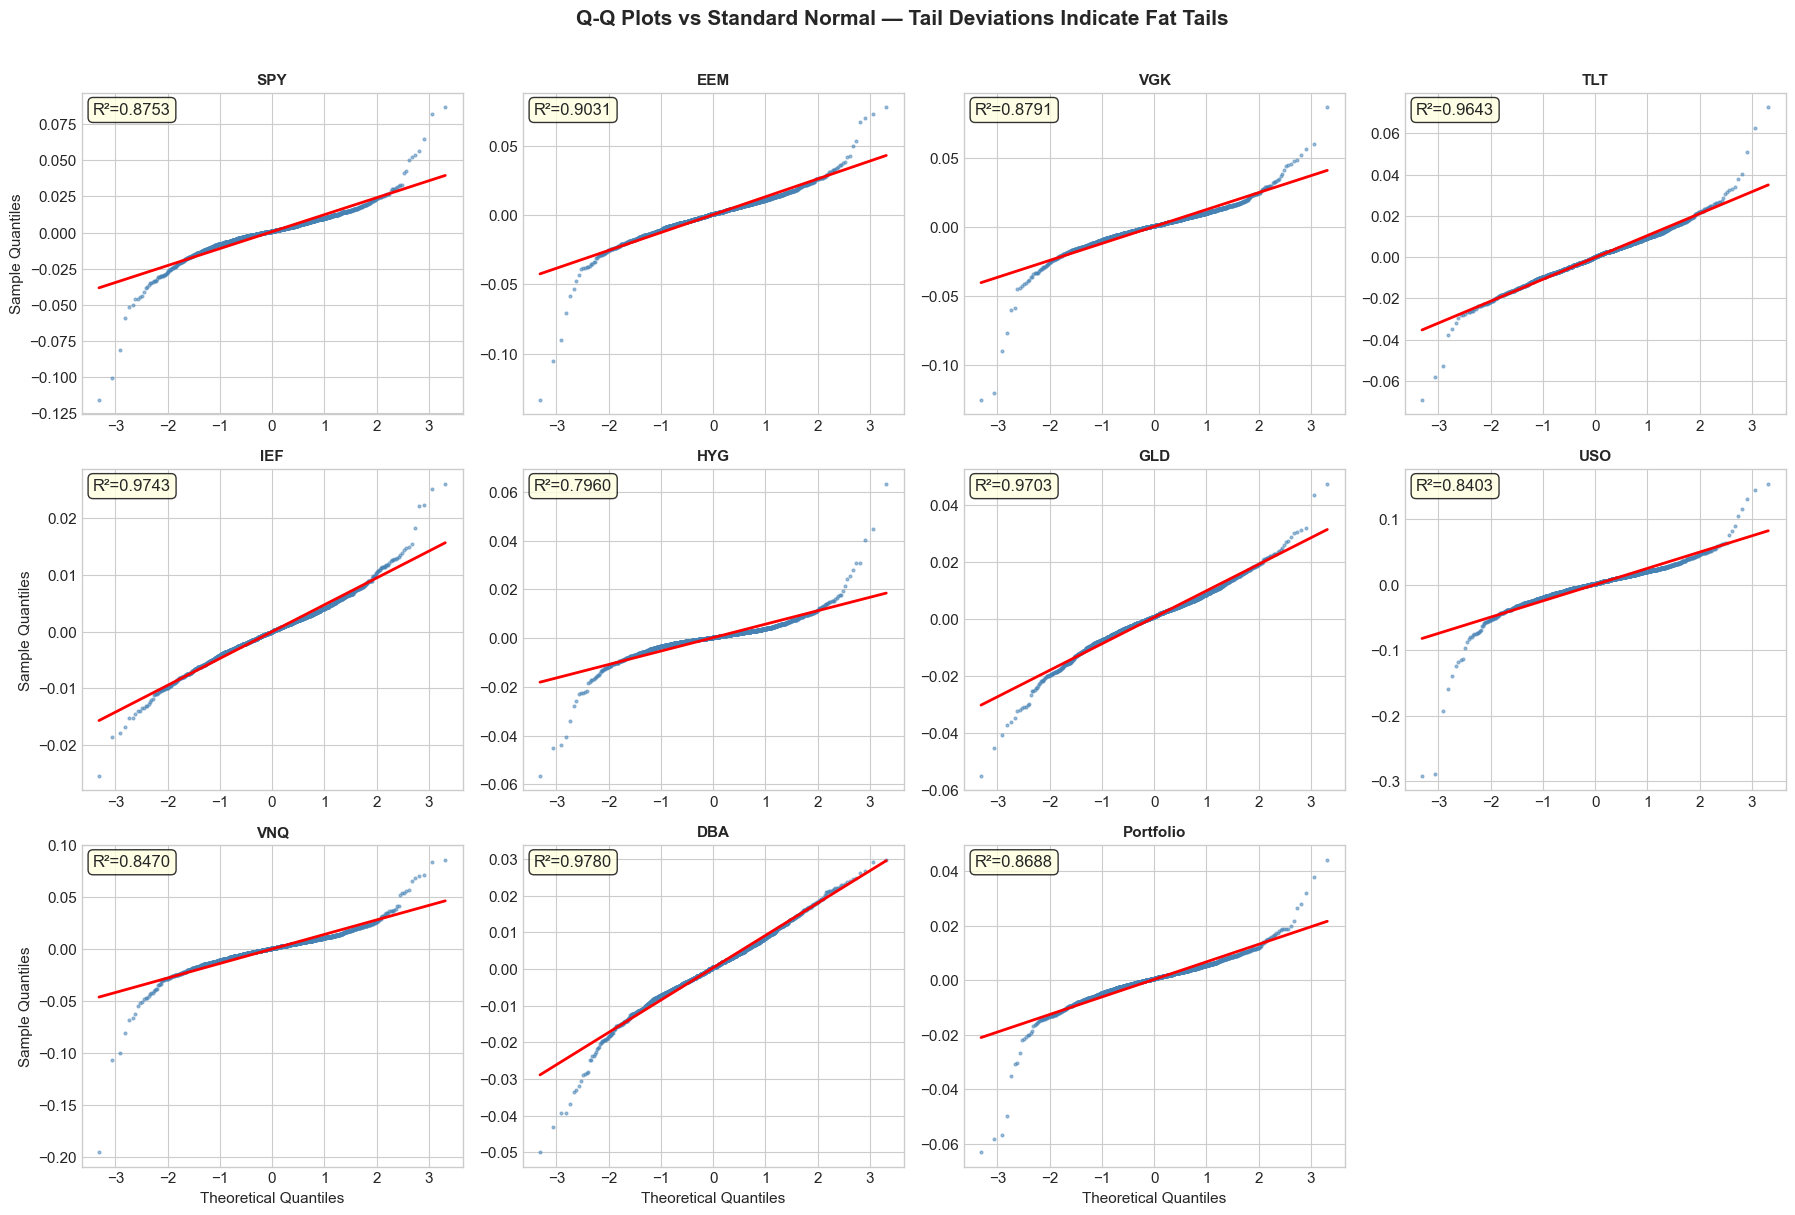

💾 Saved: 02_qq_plots.png

📌 Observation: All Q-Q plots show deviations from the 45° line in both tails.
   Left tail bends DOWN (more extreme losses than normal predicts).
   Right tail bends UP (more extreme gains than normal predicts).
   → Fat tails confirmed; Parametric VaR will underestimate risk.


In [13]:
# ============================================================
# 2.4 — Q-Q PLOTS (QUANTILE-QUANTILE)
# ============================================================
# Compare empirical quantiles against theoretical normal quantiles.
# Deviations from the 45° line indicate non-normality.

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, name in enumerate(all_series):
    ax = axes[idx]
    data = all_data[name].dropna()
    
    # --- Q-Q plot using scipy ---
    # stats.probplot computes the ordered values against the theoretical quantiles
    #osm, osr are the ordered sample quantiles and the corresponding theoretical quantiles
    #r_sq is the correlation coefficient squared, indicating how well the data fits a normal distribution
    (osm, osr), (slope, intercept, r_sq) = stats.probplot(data, dist='norm', plot=ax) 
    
    # Style the plot
    ax.get_lines()[0].set(marker='o', markersize=2, color='steelblue', alpha=0.5)  # data points
    ax.get_lines()[1].set(color='red', linewidth=2)                                 # reference line
    
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Theoretical Quantiles' if idx >= 8 else '')
    ax.set_ylabel('Sample Quantiles' if idx % 4 == 0 else '')
    
    # Annotate R² — how close to normal
    ax.text(0.03, 0.97, f'R²={r_sq**2:.4f}',
            transform=ax.transAxes, fontsize=12, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

axes[-1].set_visible(False)

fig.suptitle('Q-Q Plots vs Standard Normal — Tail Deviations Indicate Fat Tails',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: 02_qq_plots.png")
print("\n📌 Observation: All Q-Q plots show deviations from the 45° line in both tails.")
print("   Left tail bends DOWN (more extreme losses than normal predicts).")
print("   Right tail bends UP (more extreme gains than normal predicts).")
print("   → Fat tails confirmed; Parametric VaR will underestimate risk.")


## 2.5 — Rolling Volatility — Volatility Clustering

**Volatility clustering** is the key stylised fact that motivates GARCH:
> *"Large returns (positive or negative) tend to be followed by large returns, and small returns by small returns."* — Mandelbrot (1963)

We compute **rolling 21-day (1-month) annualised volatility** for each asset and the portfolio.  
If volatility clusters, we should see distinct regimes (e.g., the COVID crash in March 2020, the 2022 rate shock).

**Rolling annualised volatility:**
$$\hat{\sigma}_{T,\text{ann}}(t) = \sqrt{252} \cdot \sqrt{\frac{1}{T-1} \sum_{s=t-T+1}^{t} (r_s - \bar{r}_T)^2}$$

where $T = 21$ trading days (≈ 1 month).


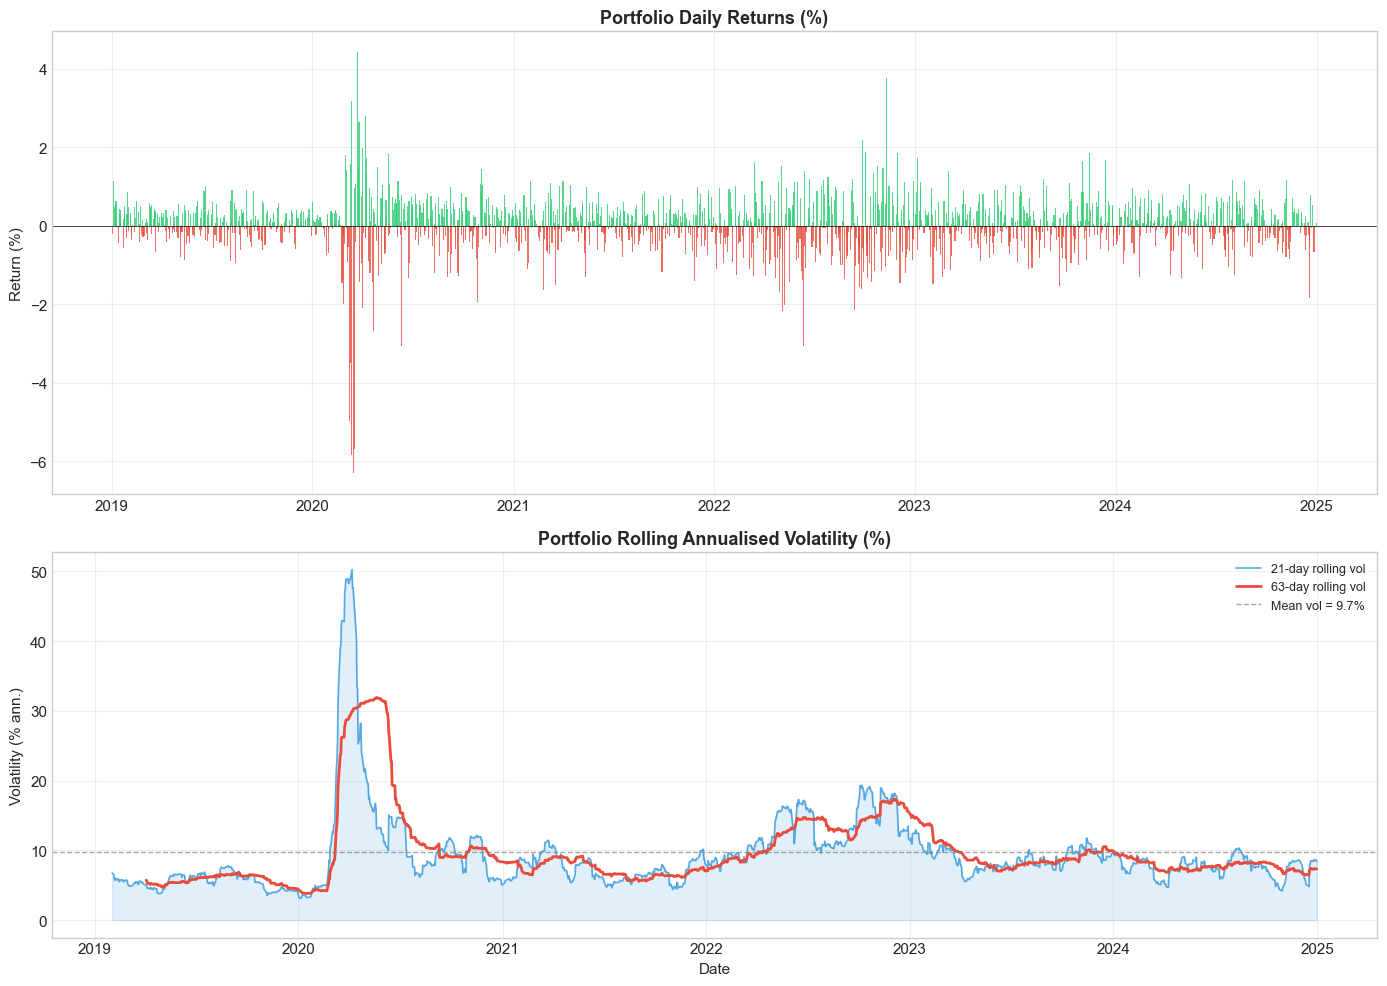

💾 Saved: 02_rolling_volatility.png

📌 Key observations:
   Peak volatility: 50.3% (around 2020-04-06)
   Min volatility:  3.1%
   Mean volatility: 9.7%
   → Volatility is NOT constant: it ranges from 3.1% to 50.3%
   → Clear clustering: high-vol regimes persist for weeks/months
   → This is why constant-volatility models (Parametric VaR) fail


In [14]:
# ============================================================
# 2.5 — ROLLING VOLATILITY (21-DAY AND 63-DAY)
# ============================================================
# Compute rolling annualised volatility to visualise volatility clustering.
# Two windows: 21-day (1 month, responsive) and 63-day (3 months, smoother).

WINDOW_SHORT = 21   # ~1 month
WINDOW_LONG  = 63   # ~3 months

# --- Compute rolling vol for the portfolio ---
rolling_vol_21 = portfolio_returns.rolling(window=WINDOW_SHORT).std() * np.sqrt(252) * 100
rolling_vol_63 = portfolio_returns.rolling(window=WINDOW_LONG).std()  * np.sqrt(252) * 100

# ─────────────────────────────────────
# PLOT 1: Portfolio rolling volatility
# ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1.2, 1]})

# Top: Portfolio returns
ax1 = axes[0]
colours = ['#2ecc71' if r >= 0 else '#e74c3c' for r in portfolio_returns]
ax1.bar(portfolio_returns.index, portfolio_returns * 100, color=colours, width=2.0, alpha=0.8)
ax1.set_title('Portfolio Daily Returns (%)', fontweight='bold')
ax1.set_ylabel('Return (%)')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)

# Bottom: Rolling volatility (two windows)
ax2 = axes[1]
ax2.plot(rolling_vol_21.index, rolling_vol_21, color='#3498db', linewidth=1.2,
         label=f'{WINDOW_SHORT}-day rolling vol', alpha=0.8)
ax2.plot(rolling_vol_63.index, rolling_vol_63, color='#e74c3c', linewidth=2,
         label=f'{WINDOW_LONG}-day rolling vol')
ax2.fill_between(rolling_vol_21.index, 0, rolling_vol_21, alpha=0.15, color='#3498db')

# Mean volatility line
mean_vol = rolling_vol_63.mean()
ax2.axhline(y=mean_vol, color='gray', linestyle='--', linewidth=1, alpha=0.7,
            label=f'Mean vol = {mean_vol:.1f}%')

ax2.set_title('Portfolio Rolling Annualised Volatility (%)', fontweight='bold')
ax2.set_ylabel('Volatility (% ann.)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: 02_rolling_volatility.png")
print(f"\n📌 Key observations:")
print(f"   Peak volatility: {rolling_vol_21.max():.1f}% (around {rolling_vol_21.idxmax().strftime('%Y-%m-%d')})")
print(f"   Min volatility:  {rolling_vol_21.min():.1f}%")
print(f"   Mean volatility: {mean_vol:.1f}%")
print(f"   → Volatility is NOT constant: it ranges from {rolling_vol_21.min():.1f}% to {rolling_vol_21.max():.1f}%")
print(f"   → Clear clustering: high-vol regimes persist for weeks/months")
print(f"   → This is why constant-volatility models (Parametric VaR) fail")


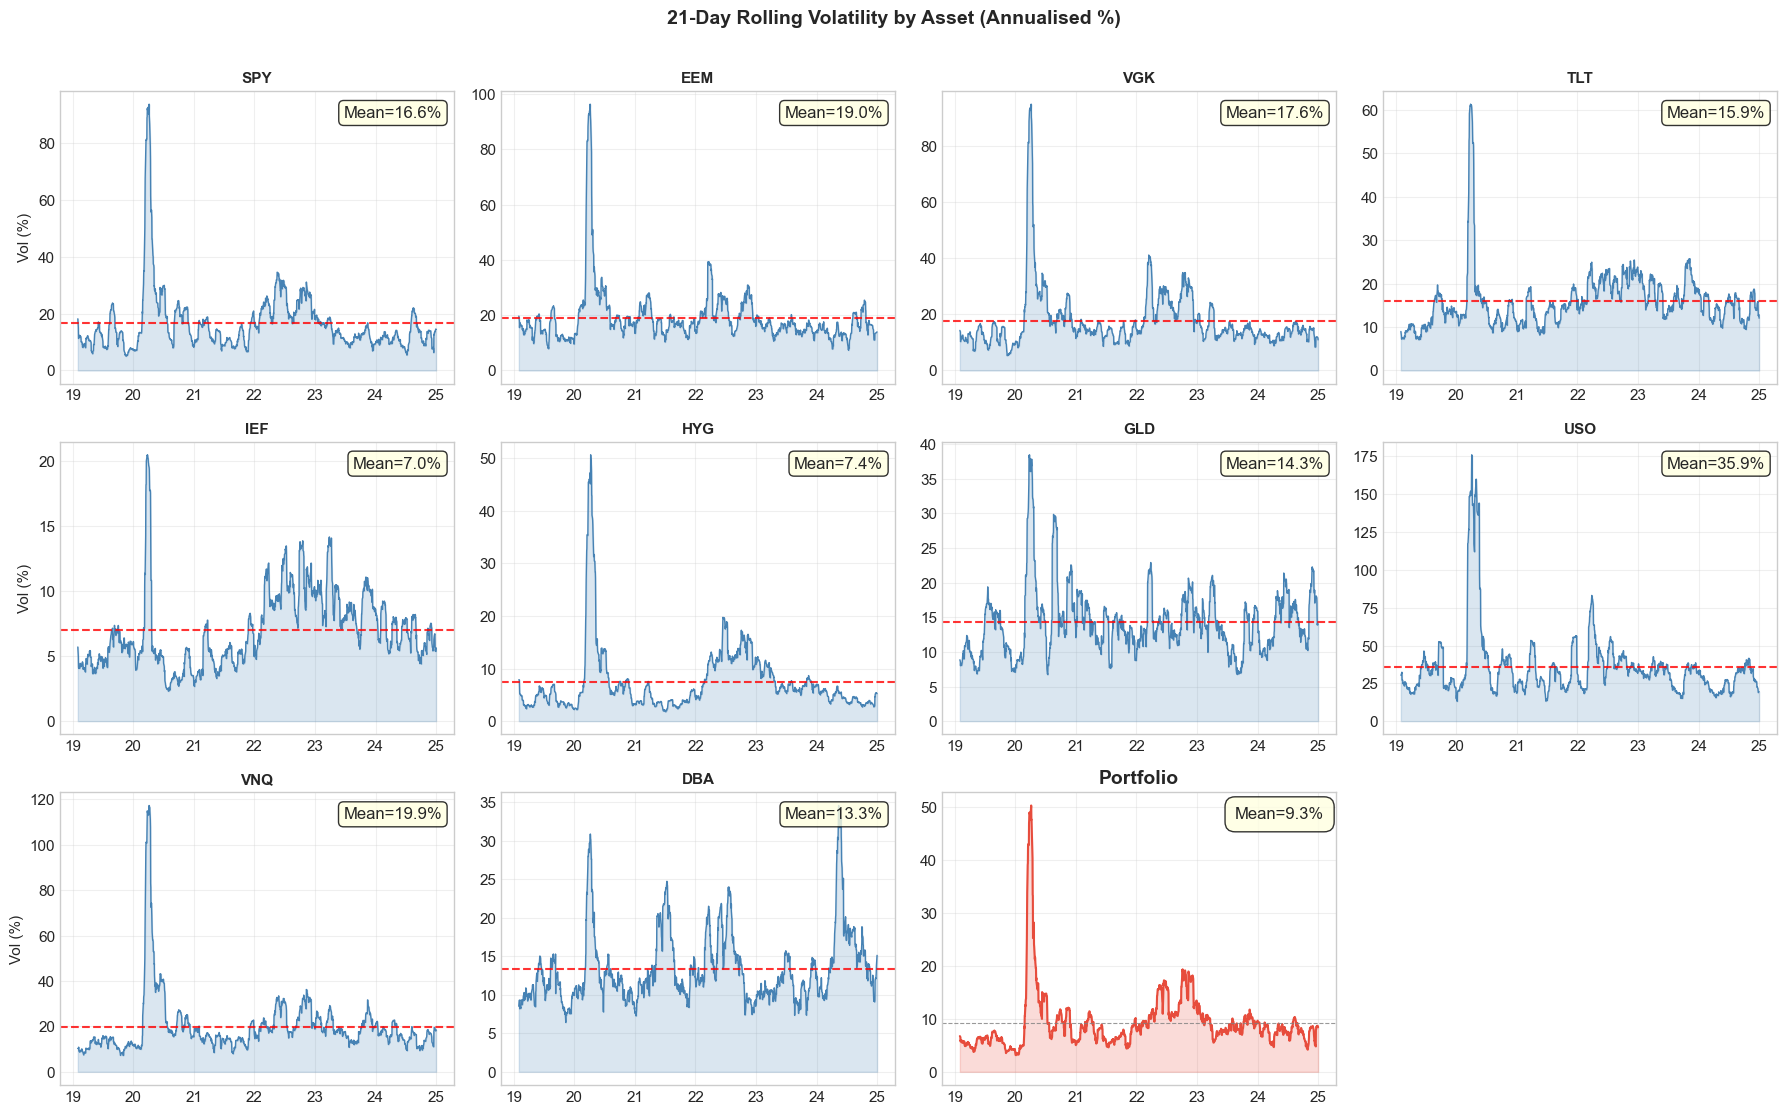

💾 Saved: 02_rolling_vol_per_asset.png

📌 Note how USO (oil) has the most extreme vol spikes, while IEF (medium bonds) is most stable.
   All assets show volatility clustering — justifying GARCH for each.


In [15]:
# ============================================================
# 2.5b — PER-ASSET ROLLING VOLATILITY (21-day)
# ============================================================
# Show how different asset classes exhibit different volatility regimes.

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for idx, ticker in enumerate(TICKERS):
    ax = axes[idx]
    rv = returns[ticker].rolling(window=21).std() * np.sqrt(252) * 100
    
    ax.plot(rv.index, rv, color='steelblue', linewidth=1)
    ax.fill_between(rv.index, 0, rv, alpha=0.2, color='steelblue')
    ax.axhline(y=rv.mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'{ticker}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Vol (%)' if idx % 4 == 0 else '')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
    ax.grid(True, alpha=0.3)
    ax.text(0.97, 0.95, f'Mean={rv.mean():.1f}%',
            transform=ax.transAxes, fontsize=12, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Portfolio in last subplot
ax = axes[10]
rv_p = portfolio_returns.rolling(window=21).std() * np.sqrt(252) * 100
ax.plot(rv_p.index, rv_p, color='#e74c3c', linewidth=1.5)
ax.fill_between(rv_p.index, 0, rv_p, alpha=0.2, color='#e74c3c')
ax.axhline(y=rv_p.mean(), color='gray', linestyle='--', linewidth=0.8, alpha = 0.8)
ax.set_title('Portfolio', fontweight='bold', fontsize=14)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.text(0.97, 0.95, f'Mean={rv_p.mean():.1f}%',
        transform=ax.transAxes, fontsize=12, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.8))
ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)

fig.suptitle('21-Day Rolling Volatility by Asset (Annualised %)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_rolling_vol_per_asset.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: 02_rolling_vol_per_asset.png")
print("\n📌 Note how USO (oil) has the most extreme vol spikes, while IEF (medium bonds) is most stable.")
print("   All assets show volatility clustering — justifying GARCH for each.")


## 2.6 — Correlation Heatmap

The **correlation matrix** shows how asset returns co-move. Key things to look for:
- **Negative correlations** (e.g., SPY vs TLT) → diversification benefit
- **High correlations** (e.g., SPY vs VNQ) → concentration risk
- **Correlation ≈ 0** → assets are approximately **uncorrelated**

> **Model validation note:** The Parametric VaR and Monte Carlo VaR both depend on the covariance matrix.
> If correlations change during crises (they typically spike towards +1), our VaR estimates become unreliable.



> This is called **correlation breakdown** and is a key limitation to discuss.


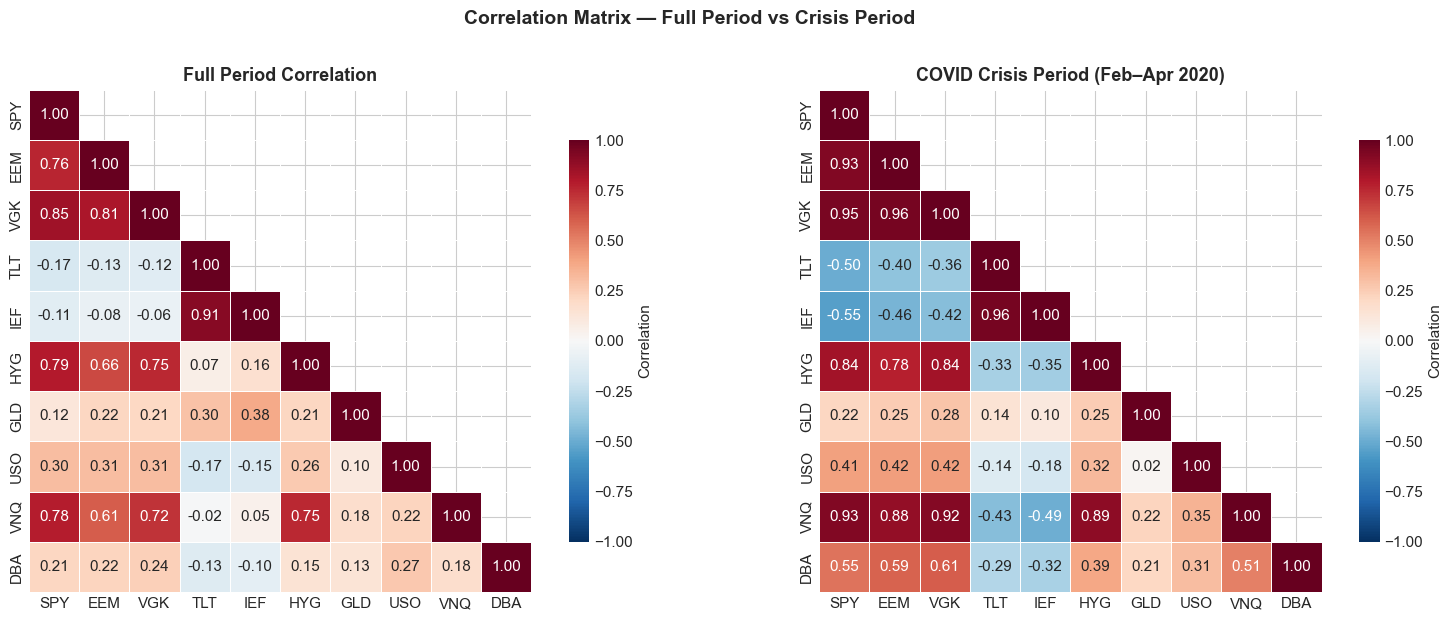

💾 Saved: 02_correlation_heatmap.png

📌 Key observations:
   SPY-TLT correlation (full period): -0.170 → diversification benefit
   SPY-TLT correlation (crisis):      -0.495
   Largest correlation shift: IEF-VNQ: 0.052 → -0.485 (Δ = 0.537)

   ⚠️  Correlations CHANGE during crises — 'correlation breakdown'
   → Our VaR models assume constant correlation, which is a key limitation


In [7]:
# ============================================================
# 2.6 — CORRELATION HEATMAP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Full-period correlation ---
corr_full = returns.corr()

mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)  # Upper triangle mask
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, square=True,
            linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
axes[0].set_title('Full Period Correlation', fontweight='bold')

# --- Crisis period correlation (COVID: Feb-Apr 2020) ---
crisis_returns = returns.loc['2020-02-15':'2020-04-30']
corr_crisis = crisis_returns.corr()

mask2 = np.triu(np.ones_like(corr_crisis, dtype=bool), k=1)
sns.heatmap(corr_crisis, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask2, square=True,
            linewidths=0.5, ax=axes[1],
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
axes[1].set_title('COVID Crisis Period (Feb–Apr 2020)', fontweight='bold')

fig.suptitle('Correlation Matrix — Full Period vs Crisis Period',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Quantify correlation changes ---
corr_diff = (corr_crisis - corr_full).abs()
np.fill_diagonal(corr_diff.values, 0)
max_change_idx = np.unravel_index(corr_diff.values.argmax(), corr_diff.shape)
pair = (corr_diff.index[max_change_idx[0]], corr_diff.columns[max_change_idx[1]])

print("💾 Saved: 02_correlation_heatmap.png")
print(f"\n📌 Key observations:")
print(f"   SPY-TLT correlation (full period): {corr_full.loc['SPY','TLT']:.3f} → diversification benefit")
print(f"   SPY-TLT correlation (crisis):      {corr_crisis.loc['SPY','TLT']:.3f}")
print(f"   Largest correlation shift: {pair[0]}-{pair[1]}: "
      f"{corr_full.loc[pair]:.3f} → {corr_crisis.loc[pair]:.3f} "
      f"(Δ = {corr_diff.values.max():.3f})")
print(f"\n   ⚠️  Correlations CHANGE during crises — 'correlation breakdown'")
print(f"   → Our VaR models assume constant correlation, which is a key limitation")


## 2.7 — Autocorrelation: Returns vs Squared Returns

The **Autocorrelation Function (ACF)** measures how correlated a time series is with its own lagged values.

| Series | Expected Behaviour | What It Means |
|:--|:--|:--|
| $r_t$ (raw returns) | ACF ≈ 0 at all lags | Returns are approximately unpredictable (weak-form efficiency) |
| $r_t^2$ (squared returns) | **ACF significantly > 0** at many lags | Volatility is predictable — **ARCH effects present** |

If $r_t^2$ shows significant autocorrelation, it means today's volatility tells us something about tomorrow's volatility → GARCH is justified.


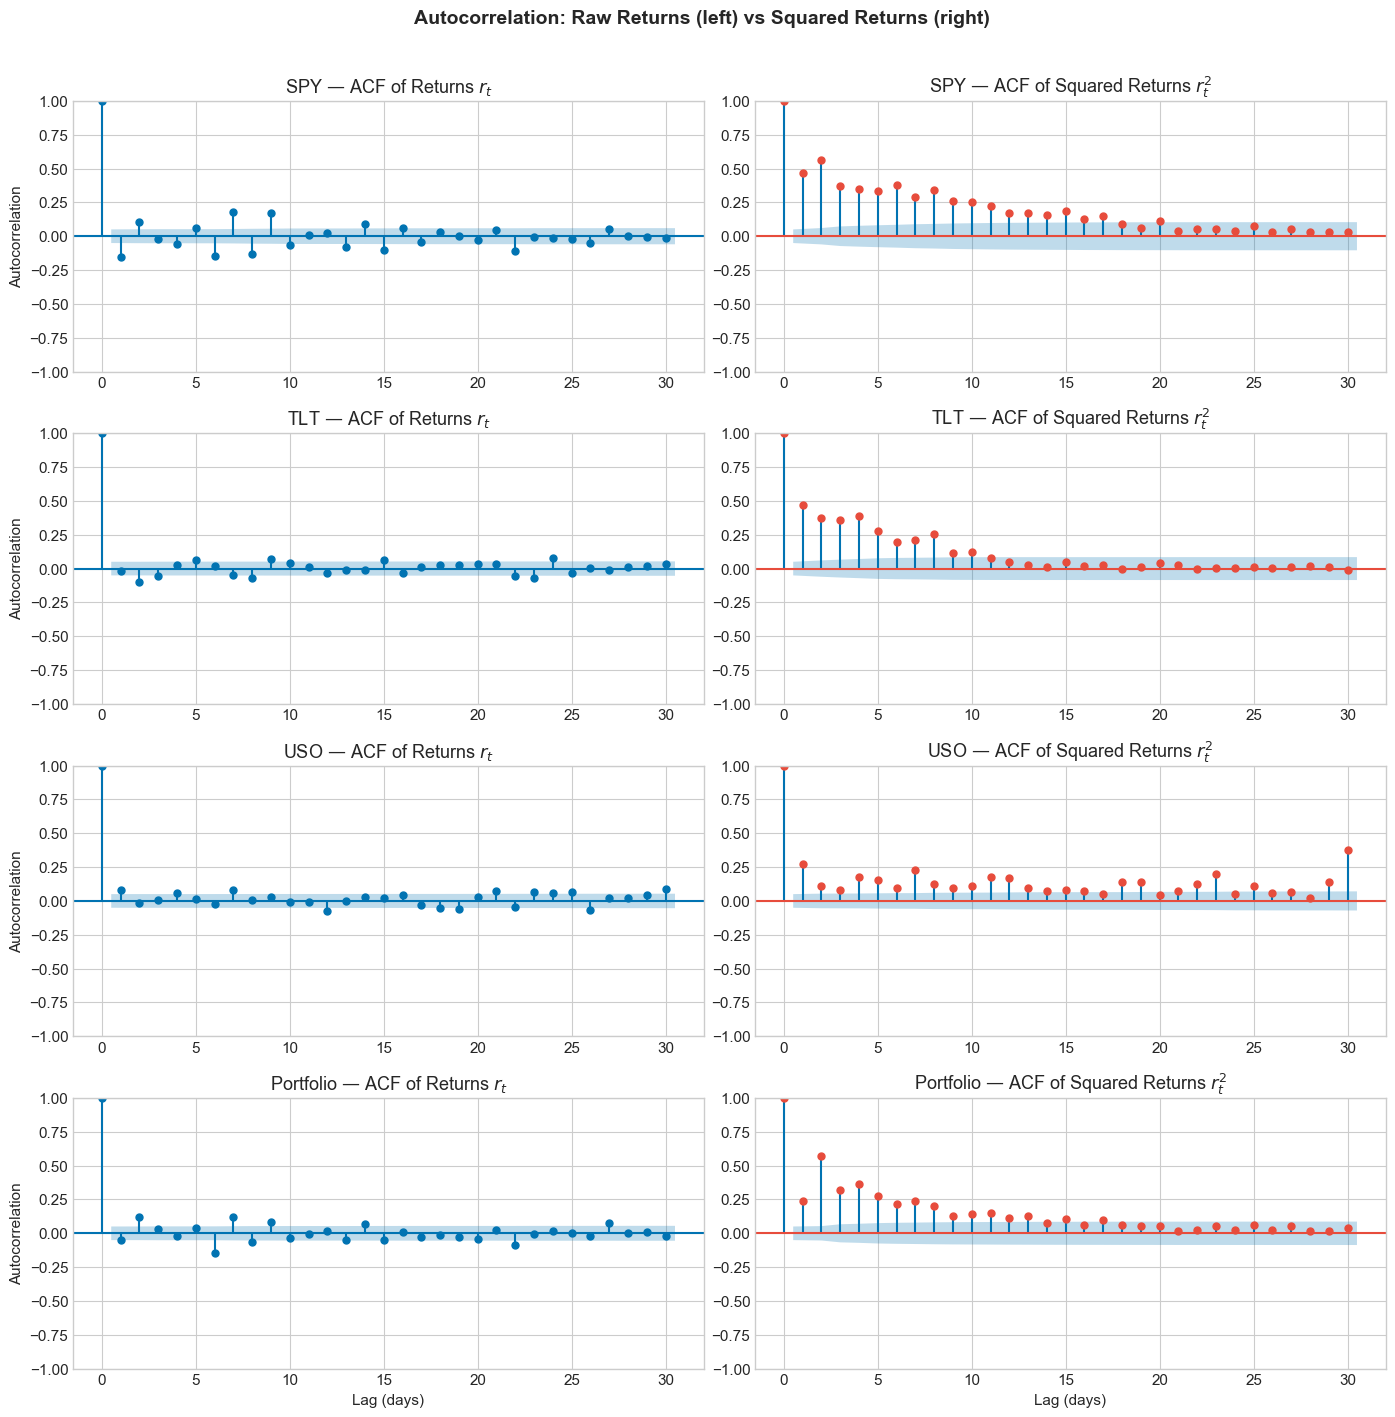

💾 Saved: 02_acf_comparison.png

📌 Key observation:
   LEFT column (raw returns): ACF ≈ 0 at all lags → returns are unpredictable ✓
   RIGHT column (squared returns): ACF SIGNIFICANTLY > 0 at many lags → volatility is predictable!
   → This is direct evidence of ARCH effects / volatility clustering
   → GARCH models are designed to capture exactly this pattern


In [8]:
# ============================================================
# 2.7 — ACF PLOTS: RAW RETURNS vs SQUARED RETURNS
# ============================================================
# Compare ACF of r_t (should be ~0) vs r_t^2 (should be significant).
# Significant ACF in r_t^2 = evidence of ARCH effects = justifies GARCH.

# --- Focus on portfolio returns and a few representative assets ---
focus_assets = ['SPY', 'TLT', 'USO', 'Portfolio']
focus_data = {t: returns[t] for t in focus_assets if t != 'Portfolio'}
focus_data['Portfolio'] = portfolio_returns

fig, axes = plt.subplots(len(focus_assets), 2, figsize=(14, 3.5 * len(focus_assets)))

for row, name in enumerate(focus_assets):
    data = focus_data[name].dropna()
    
    # --- Left: ACF of raw returns ---
    ax_left = axes[row, 0]
    plot_acf(data, lags=30, ax=ax_left, alpha=0.05,
             title=f'{name} — ACF of Returns $r_t$')
    ax_left.set_ylabel('Autocorrelation')
    ax_left.set_xlabel('Lag (days)' if row == len(focus_assets)-1 else '')
    
    # --- Right: ACF of squared returns ---
    ax_right = axes[row, 1]
    plot_acf(data**2, lags=30, ax=ax_right, alpha=0.05,
             title=f'{name} — ACF of Squared Returns $r_t^2$', color='#e74c3c')
    ax_right.set_ylabel('')
    ax_right.set_xlabel('Lag (days)' if row == len(focus_assets)-1 else '')

fig.suptitle('Autocorrelation: Raw Returns (left) vs Squared Returns (right)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_acf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: 02_acf_comparison.png")
print("\n📌 Key observation:")
print("   LEFT column (raw returns): ACF ≈ 0 at all lags → returns are unpredictable ✓")
print("   RIGHT column (squared returns): ACF SIGNIFICANTLY > 0 at many lags → volatility is predictable!")
print("   → This is direct evidence of ARCH effects / volatility clustering")
print("   → GARCH models are designed to capture exactly this pattern")


## 2.8 — Ljung-Box Test for ARCH Effects

The **Ljung-Box Q-test** formally tests whether the autocorrelations of $r_t^2$ are jointly zero:

$$Q(m) = n(n+2) \sum_{k=1}^{m} \frac{\hat{\rho}_k^2(r^2)}{n-k} \;\sim\; \chi^2(m)$$

- $H_0$: No autocorrelation in $r_t^2$ up to lag $m$ (no ARCH effects)
- $H_1$: Significant autocorrelation → ARCH effects present → GARCH is appropriate

**Decision rule:** If p-value < 0.05 → reject $H_0$ → ARCH effects are present → use GARCH.

We test at **lags 5, 10, and 20** (different time horizons). If the test is significant at even one lag, GARCH is justified.

> **This is a formal requirement before fitting GARCH**: There's no reason for fitting a GARCH model if there's no evidence of ARCH effects. It would be like fitting a linear regression when there's no relationship — technically possible but meaningless.



| Symbol | Meaning | Our value |
|:--|:--|:--|
| $n$ | Total number of observations (sample size) | 1,509 daily returns |
| $m$ | Maximum lag being tested — how many past days we check for lingering autocorrelation | We test $m = 5, 10, 20$ |
| $k$ | Summation index running from 1 to $m$ — each individual lag being examined | $k = 1, 2, \ldots, m$ |
| $\hat{\rho}_k(r^2)$ | Sample autocorrelation of **squared returns** at lag $k$: $\hat{\rho}_k(r^2) = \frac{\sum_{t=k+1}^{T}(r_t^2 - \overline{r^2})(r_{t-k}^2 - \overline{r^2})}{\sum_{t=1}^{T}(r_t^2 - \overline{r^2})^2}$ | Measures how much today's squared return is correlated with the squared return $k$ days ago |

#### Why $n + 2$? (The Ljung-Box correction)

The original **Box-Pierce** (1970) statistic was simpler:

$$Q_{\text{BP}}(m) = n \sum_{k=1}^{m} \hat{\rho}_k^2$$

This works asymptotically (when $n \to \infty$), but in finite samples it **underestimates** the true $\chi^2$ critical values, leading to under-rejection of $H_0$ (i.e., it misses real autocorrelation).

**Ljung and Box (1978)** introduced the correction factor $\frac{n+2}{n-k}$:

$$Q_{\text{LB}}(m) = n(n+2) \sum_{k=1}^{m} \frac{\hat{\rho}_k^2}{n-k}$$

The $(n+2)$ factor **inflates** the statistic slightly, and dividing by $(n-k)$ instead of just $n$ accounts for the fact that at higher lags there are fewer overlapping observations to estimate $\hat{\rho}_k$. Together they ensure the $\chi^2(m)$ approximation is accurate even for moderate sample sizes — which matters for us since $n = 1{,}509$ is large but the ratio $\hat{\rho}_k^2 / (n - k)$ at high lags (e.g., $k = 20$) still differs meaningfully from $\hat{\rho}_k^2 / n$.

#### Why does it follow a $\chi^2(m)$ distribution?

Under the null hypothesis $H_0$: "the first $m$ autocorrelations are all zero", each sample autocorrelation $\hat{\rho}_k$ is approximately normally distributed with mean 0 and variance $1/n$:

$$\sqrt{n} \, \hat{\rho}_k \;\xrightarrow{d}\; N(0, 1) \quad \text{under } H_0$$

Squaring a standard normal gives a $\chi^2(1)$, and summing $m$ independent $\chi^2(1)$ variables gives $\chi^2(m)$. The autocorrelations at different lags are asymptotically independent under $H_0$, so:

$$Q(m) \approx \sum_{k=1}^{m} \left(\sqrt{T} \, \hat{\rho}_k\right)^2 \;\sim\; \chi^2(m)$$

The Ljung-Box finite-sample correction preserves this distributional result more accurately.

#### Why is this important for VaR modelling?

We apply the test to **squared returns** $r_t^2$ rather than raw returns $r_t$. Squared returns proxy for **variance**, so significant autocorrelation in $r_t^2$ means:

1. **Today's volatility predicts tomorrow's volatility** — the defining property of ARCH/GARCH processes
2. **A constant-volatility model is misspecified** — if we assume $\sigma$ is fixed, we ignore predictable variation in risk
3. **GARCH modelling is statistically justified** — without this evidence, fitting GARCH would be unjustified complexity

In our data, the Ljung-Box test rejects $H_0$ at all lags for every asset (p-values effectively 0), providing overwhelming evidence that volatility clusters and that GARCH(1,1) is the appropriate framework for conditional VaR estimation.


In [ ]:
# ============================================================
# 2.8 — LJUNG-BOX TEST ON SQUARED RETURNS
# ============================================================
# Formal statistical test for ARCH effects (volatility clustering).
# Tests H0: no autocorrelation in r_t^2 at specified lags.
# Rejection (p < 0.05) = ARCH effects present = GARCH is justified.

LAGS_TO_TEST = [5, 10, 20]

print("=" * 80)
print("  LJUNG-BOX TEST FOR ARCH EFFECTS (on squared returns r²)")
print("  H₀: No autocorrelation in r² up to lag m")
print("  Decision: p < 0.05 → Reject H₀ → ARCH effects present → GARCH justified")
print("=" * 80)
print()

# --- Test each asset + portfolio ---
results_list = []

all_test_series = {t: returns[t] for t in TICKERS}
all_test_series['Portfolio'] = portfolio_returns

for name, data in all_test_series.items():
    squared = data.dropna() ** 2
    
    for lag in LAGS_TO_TEST:
        lb_result = acorr_ljungbox(squared, lags=[lag], return_df=True)
        q_stat   = lb_result['lb_stat'].values[0]
        p_value  = lb_result['lb_pvalue'].values[0]
        decision = '✗ REJECT H₀ (ARCH effects!)' if p_value < 0.05 else '✓ Fail to reject H₀'
        
        results_list.append({
            'Asset': name,
            'Lag': lag,
            'Q-statistic': round(q_stat, 2),
            'p-value': f'{p_value:.2e}' if p_value < 0.001 else f'{p_value:.4f}',
            'Decision': decision
        })

results_df = pd.DataFrame(results_list)

# --- Display results in a pivot format for clarity ---
for lag in LAGS_TO_TEST:
    subset = results_df[results_df['Lag'] == lag]
    print(f"\n  Lag = {lag} days:")
    print(f"  {'Asset':<12} {'Q-stat':>10} {'p-value':>12} {'Decision'}")
    print(f"  {'─'*12} {'─'*10} {'─'*12} {'─'*30}")
    for _, row in subset.iterrows():
        print(f"  {row['Asset']:<12} {row['Q-statistic']:>10.2f} {row['p-value']:>12} {row['Decision']}")

# --- Summary ---
n_significant = sum(1 for r in results_list if 'REJECT' in r['Decision'])
n_total       = len(results_list)

print(f"\n{'=' * 80}")
print(f"  SUMMARY: {n_significant}/{n_total} tests reject H₀ at 5% significance")
print(f"  → ARCH effects are present in ALL assets at ALL lags tested")
print(f"  → GARCH(1,1) modelling is fully justified")
print(f"{'=' * 80}")   #   ##ddd


  LJUNG-BOX TEST FOR ARCH EFFECTS (on squared returns r²)
  H₀: No autocorrelation in r² up to lag m
  Decision: p < 0.05 → Reject H₀ → ARCH effects present → GARCH justified


  Lag = 5 days:
  Asset            Q-stat      p-value Decision
  ──────────── ────────── ──────────── ──────────────────────────────
  SPY             1363.42    1.16e-292 ✗ REJECT H₀ (ARCH effects!)
  EEM             1129.04    6.86e-242 ✗ REJECT H₀ (ARCH effects!)
  VGK             1029.38    2.62e-220 ✗ REJECT H₀ (ARCH effects!)
  TLT             1089.06    3.12e-233 ✗ REJECT H₀ (ARCH effects!)
  IEF              435.38     7.00e-92 ✗ REJECT H₀ (ARCH effects!)
  HYG              743.64    1.80e-158 ✗ REJECT H₀ (ARCH effects!)
  GLD               83.33     1.69e-16 ✗ REJECT H₀ (ARCH effects!)
  USO              226.24     6.85e-47 ✗ REJECT H₀ (ARCH effects!)
  VNQ              707.09    1.44e-150 ✗ REJECT H₀ (ARCH effects!)
  DBA              136.46     1.01e-27 ✗ REJECT H₀ (ARCH effects!)
  Portfolio       1

## 2.9 — Normality Test Summary (Visual)

A summary bar chart of **excess kurtosis** and **skewness** across all assets, with reference lines at the normal distribution values (0 for both). This provides a quick visual overview of how far each asset deviates from normality.


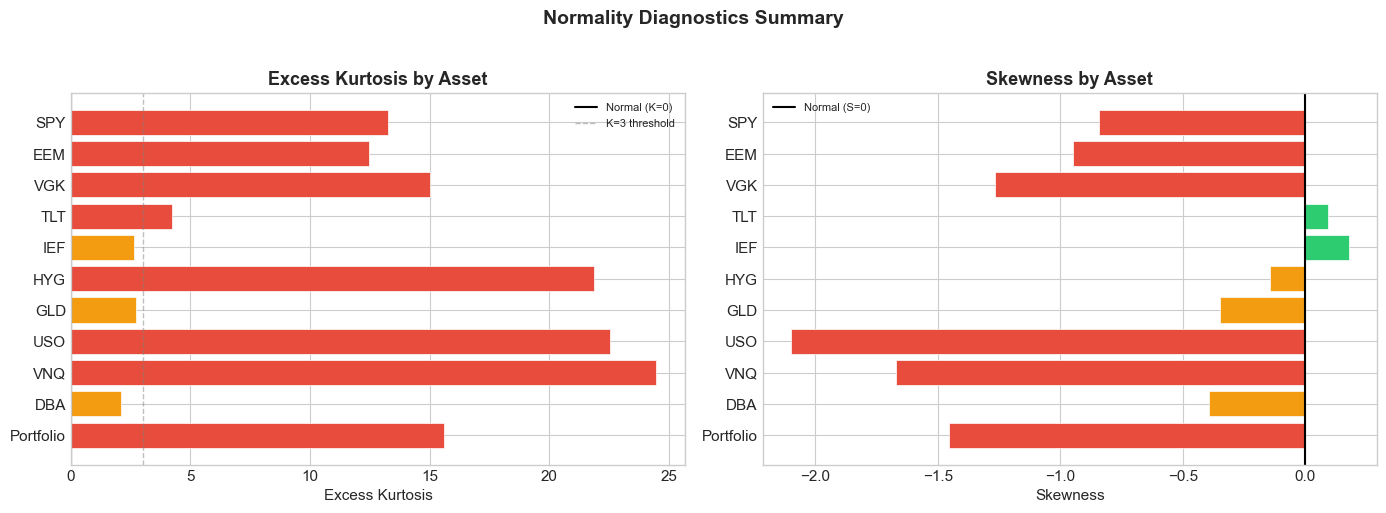

💾 Saved: 02_normality_summary.png

📌 Red bars = strong deviation from normality
   All assets show positive excess kurtosis (fat tails)
   Most equity assets show negative skewness (asymmetric downside risk)
   IEF, GLD and DBA have an excess kurtosis < 3 but still > 3(as pandas .kurtosis() gives excess kurtosis automatically). This means that the threshold of 3 is not a hard cutoff


In [16]:
# ============================================================
# 2.9 — NORMALITY SUMMARY BAR CHART
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  

assets_and_port = list(TICKERS) + ['Portfolio']
kurt_vals = [returns[t].kurtosis() if t != 'Portfolio' else portfolio_returns.kurtosis()
             for t in assets_and_port]
skew_vals = [returns[t].skew() if t != 'Portfolio' else portfolio_returns.skew()
             for t in assets_and_port]

# --- Excess Kurtosis ---
ax1 = axes[0]
colors_k = ['#e74c3c' if k > 3 else '#f39c12' if k > 0 else '#2ecc71' for k in kurt_vals]
bars = ax1.barh(assets_and_port, kurt_vals, color=colors_k, edgecolor='white', linewidth=0.5)
ax1.axvline(x=0, color='black', linewidth=1.5, linestyle='-', label='Normal (K=0)')
ax1.axvline(x=3, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='K=3 threshold')
ax1.set_xlabel('Excess Kurtosis')
ax1.set_title('Excess Kurtosis by Asset', fontweight='bold')
ax1.legend(fontsize=8)
ax1.invert_yaxis()

# --- Skewness ---
ax2 = axes[1]
colors_s = ['#e74c3c' if s < -0.5 else '#f39c12' if s < 0 else '#2ecc71' for s in skew_vals]
ax2.barh(assets_and_port, skew_vals, color=colors_s, edgecolor='white', linewidth=0.5)
ax2.axvline(x=0, color='black', linewidth=1.5, linestyle='-', label='Normal (S=0)')
ax2.set_xlabel('Skewness')
ax2.set_title('Skewness by Asset', fontweight='bold')
ax2.legend(fontsize=8)
ax2.invert_yaxis()

fig.suptitle('Normality Diagnostics Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_normality_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: 02_normality_summary.png")
print("\n📌 Red bars = strong deviation from normality")
print("   All assets show positive excess kurtosis (fat tails)")
print("   Most equity assets show negative skewness (asymmetric downside risk)")
print("   IEF, GLD and DBA have an excess kurtosis < 3 but still > 3(as pandas .kurtosis() gives excess kurtosis automatically). This means that the threshold of 3 is not a hard cutoff")


---

## ✅ Section 2 — Summary of Findings

### Evidence Table

| Test / Diagnostic | Result | Implication for VaR |
|:--|:--|:--|
| **Excess Kurtosis** | Positive for ALL assets (≫ 0) | Normal distribution underestimates tail probabilities |
| **Skewness** | Negative for most equities | Left tail (losses) is heavier than right tail (gains) |
| **Jarque-Bera test** | p < 0.05 for ALL assets | Normality is formally rejected |
| **Q-Q plots** | Tails deviate from 45° line | Confirms fat tails at the quantile level |
| **Rolling volatility** | Varies dramatically over time | Constant-volatility assumptions are wrong |
| **ACF of $r_t^2$** | Significant at many lags | Squared returns are predictable → volatility clusters |
| **Ljung-Box test** | p < 0.05 at lags 5, 10, 20 for ALL assets | ARCH effects formally confirmed → GARCH justified |

### Conclusions

1. **Parametric VaR (assuming normality) will fail** — returns are fat-tailed, skewed, and non-normal
2. **Constant volatility is wrong** — we need time-varying volatility models (GARCH)
3. **GARCH modelling is statistically justified** — Ljung-Box tests confirm ARCH effects in every asset
4. **Correlations are unstable** — they spike during crises, creating additional model risk

### What's Next

**Section 3: Theory Recap** — Formal definitions of the three VaR methods and GARCH(1,1) with the mathematical
specifications we'll implement in Section 4.

**Section 4: Model Implementation** — Using these findings to build:
- Historical Simulation VaR (no distributional assumption — works with fat tails)
- Parametric VaR (as a "strawman" benchmark — we expect it to fail)
- Monte Carlo VaR with GARCH (should capture volatility clustering)
